# Option pricing
Project for the Introduction to Financial Engineering class.

In [1]:
from bin_model import BinomialModel, get_up_factor, get_down_factor
from options import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt = 1 / 12
sigma = 0.3
u = get_up_factor(sigma, dt)
d = get_down_factor(sigma, dt)
S0 = 50
r = 0.02
K = 48
T = 2

N = int(T / dt) # number of periods
bin_model = BinomialModel(S0, N, dt, u, d, r)

## European options

In [3]:
eur_call = EuropeanCall(K)
eur_put = EuropeanPut(K)

eur_call_price = eur_call.price(bin_model)
eur_put_price = eur_put.price(bin_model)
print(f'European call price: {eur_call_price:.3f}')
print(f'European put price: {eur_put_price:.3f}')

European call price: 10.191
European put price: 6.309


## American options

In [4]:
ame_call = AmericanCall(K)
ame_put = AmericanPut(K)

ame_call_price = ame_call.price(bin_model)
ame_put_price = ame_put.price(bin_model)
print(f'American call price: {ame_call_price:.3f}')
print(f'American put price: {ame_put_price:.3f}')

American call price: 10.191
American put price: 6.471


## Theoretical properties checks

#### Put call parity
$$C_E + Ke^{-r * T} = P_E + S_0$$

In [5]:
lhs = eur_call_price + K * np.exp(-r * T)
rhs = eur_put_price + S0
print('put-call parity:', np.abs(lhs - rhs) < 1e-10)

put-call parity: True


#### Upper and lower bounds
European options:
$$S_0 - Ke^{-rT} \leq C_E \leq S_0,$$
$$Ke^{-rT} - S_0 \leq P_E \leq  Ke^{-rT}.$$

American options:
$$S_0-Ke^{-rT} \leq C_A \leq S_0,$$
$$K-S_0 \leq P_A \leq K.$$

In [6]:
eur_call_low = max(S0 - K * np.exp(-r * T), 0)
eur_call_hi = S0
print('European call bounds:', eur_call_low <= eur_call_price <= eur_call_hi)

eur_put_low = max(K * np.exp(-r * T) - S0, 0)
eur_put_hi = K * np.exp(-r * T)
print('European put bounds:', eur_put_low <= eur_put_price <= eur_put_hi)

ame_call_low = max(S0 - K * np.exp(-r * T), 0)
ame_call_hi = S0
print('European call bounds:', ame_call_low <= ame_call_price <= ame_call_hi)

ame_put_low = max(K - S0, 0)
ame_put_hi = K
print('European put bounds:', ame_put_low <= ame_put_price <= ame_put_hi)

European call bounds: True
European put bounds: True
European call bounds: True
European put bounds: True


## American vs. European comparison
We expect $C_A = C_E$ and $P_A \geq P_E$.

In [7]:
print('Equality in call prices:', abs(eur_call_price - ame_call_price) < 1e-6)
print('Amerian put more expensive than European:', ame_put_price >= eur_put_price)

Equality in call prices: True
Amerian put more expensive than European: True


## Sensitivity analysis
Analiza wrażliwości ceny wszystkich tych 4 rodzajów opcji ze względu na cenę wykonania K,
zapadalność T oraz parametry S0, σ i r (tzn.zbadanie,jak różne wartości tych parametróww pływają
na ceny tych opcji, w jak dużym stopniu, czy można zaobserwować pewne monotoniczności itp.).

In [8]:
# Base case parameters
BASE_S0 = 100
BASE_K = 100
BASE_T = 1.0
BASE_R = 0.05
BASE_SIGMA = 0.20
BASE_N = 500

K_eq_S0_params = {
    'S0': BASE_S0,
    'K': BASE_K,
    'T': BASE_T,
    'r': BASE_R,
    'sigma': BASE_SIGMA,
    'N': BASE_N
}

In [9]:
def analyze_sensitivity(param_name, param_values, params):
    eur_calls, eur_puts = [], []
    ame_calls, ame_puts = [], []

    payoff_calls = []
    payoff_puts = []
    
    for val in param_values:
        s0 = val if param_name == 'S0' else params['S0']
        k = val if param_name == 'K' else params['K']
        t = val if param_name == 'T' else params['T']
        r = val if param_name == 'r' else params['r']
        sigma = val if param_name == 'sigma' else params['sigma']
        
        dt = t / params['N']
        u = get_up_factor(sigma, dt)
        d = get_down_factor(sigma, dt)
        
        model = BinomialModel(S0=s0, N=params['N'], dt=dt, u=u, d=d, r=r)
        
        eur_calls.append(EuropeanCall(K=k).price(model))
        eur_puts.append(EuropeanPut(K=k).price(model))
        ame_calls.append(AmericanCall(K=k).price(model))
        ame_puts.append(AmericanPut(K=k).price(model))

        payoff_calls.append(EuropeanCall(K=k).payoff(s0))
        payoff_puts.append(EuropeanPut(K=k).payoff(s0))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(param_values, eur_calls, label='European Call', linestyle='-')
    ax.plot(param_values, ame_calls, label='American Call', linestyle='--')
    ax.plot(param_values, eur_puts, label='European Put', linestyle='-')
    ax.plot(param_values, ame_puts, label='American Put', linestyle='--')

    if param_name in ['S0', 'K']:
        ax.plot(param_values, payoff_calls, label='Call Payoff (max(S-K,0))', linestyle=':')
        ax.plot(param_values, payoff_puts, label='Put Payoff (max(K-S,0))', linestyle=':')

    
    ax.set_title(f'Option Prices vs {param_name}')
    ax.set_xlabel(param_name)
    ax.set_ylabel('Option Price')
    ax.legend()
    ax.grid(True)
    
    return ax

## What is the distribution of $S_T$?
Using the central limit theorem, it can be shown that the distribution of stock prices approaches the $\mathrm{Lognormal}(\mu, \sigma_L)$ distribution with parameters
$$\mu = \ln{S_0} + \left( r - \frac{\sigma^2}{2} \right)T$$
and
$$\sigma_L = \sigma \sqrt{T}.$$

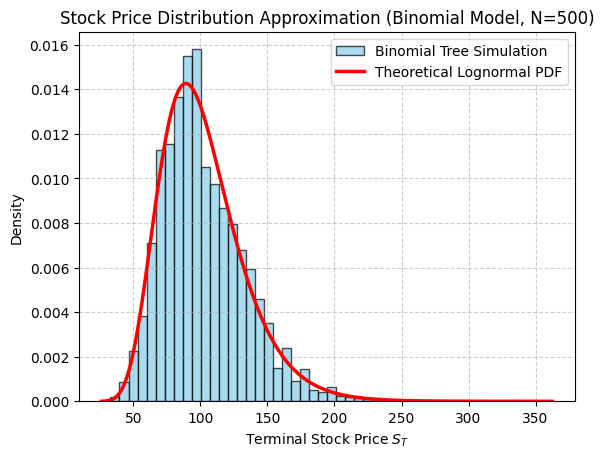

In [10]:
from scipy.stats import lognorm

n_paths = 100_000
rng = np.random.default_rng(seed=42)

dt = BASE_T / BASE_N
u = np.exp(sigma * np.sqrt(dt))
d = np.exp(-sigma * np.sqrt(dt))
p = (np.exp(r * dt) - d) / (u - d)

up_moves = rng.binomial(BASE_N, p, n_paths)
down_moves = BASE_N - up_moves
ST = BASE_S0 * (u ** up_moves) * (d ** down_moves)

mu = np.log(BASE_S0) + (r - 0.5 * sigma**2) * BASE_T
s = sigma * np.sqrt(BASE_T)  # Standard deviation of ln(S_T)
scale = np.exp(mu)           # Scaling factor for scipy (e^mu)

x = np.linspace(min(ST), max(ST), 500)
lognormal_pdf = lognorm.pdf(x, s=s, scale=scale)

plt.hist(ST, bins=50, edgecolor='black', alpha=0.7, color='skyblue', density=True, label='Binomial Tree Simulation')
plt.plot(x, lognormal_pdf, color='red', lw=2.5, label='Theoretical Lognormal PDF')
plt.title(f'Stock Price Distribution Approximation (Binomial Model, N={BASE_N})')
plt.xlabel('Terminal Stock Price $S_T$')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Sensitivity to stock price, $S_0$

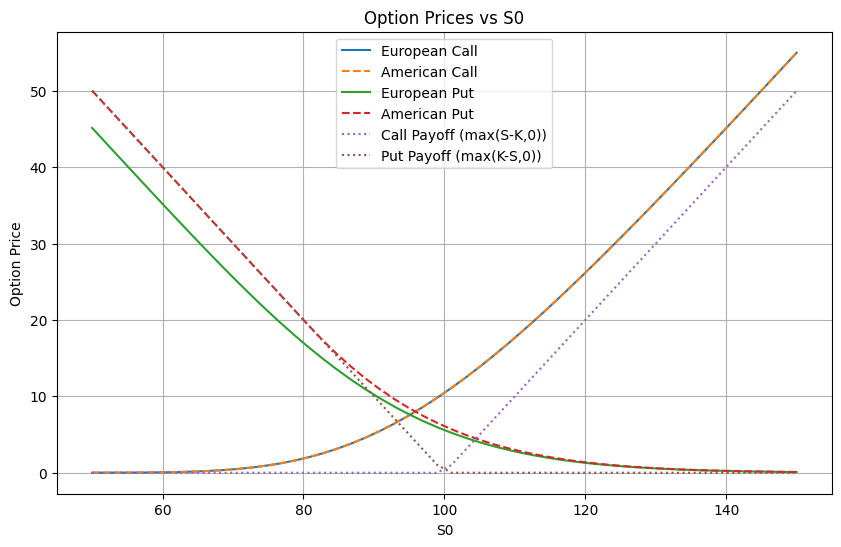

In [11]:
analyze_sensitivity('S0', np.linspace(50, 150, 50), K_eq_S0_params)
plt.show()

### Sensitivity to strike price $K$

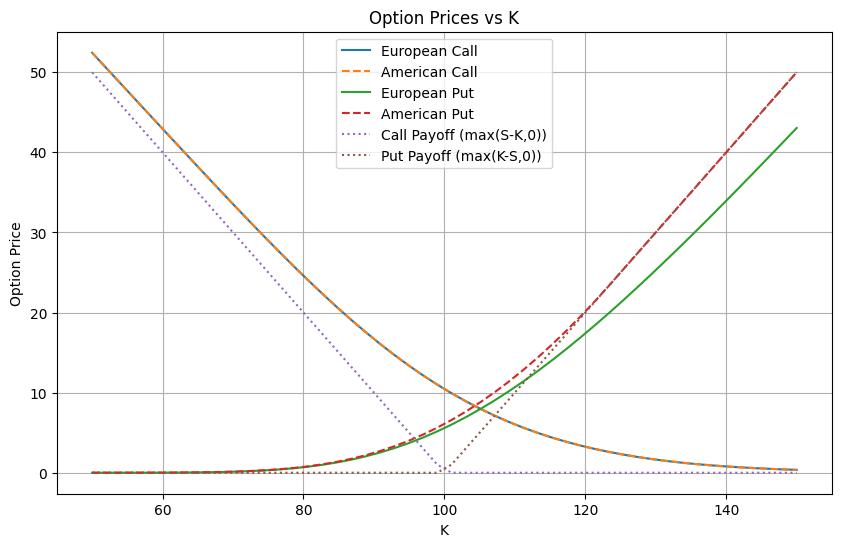

In [12]:
analyze_sensitivity('K', np.linspace(50, 150, 50), K_eq_S0_params)
plt.show()

### Sensitivity to time to maturity $T$
First, the mean of value of the stock (mean of the lognormal) is 
$$ES_T = \exp(\mu + \sigma_L^2) = S_0e^{rT}.$$
So as $T \to \infty$, the average payoff of a call is large and approximataly equal to $S_T$ ($K$ is negligible).
This feels like St. Petersburg's paradox however because when $r-\sigma^2/2 < 0$, CDF is basically a step function when $T$ is large, so the stock crashes a.s. if you wait long enough.

Depending on the sign of $r-\sigma^2/2$ two things can happen to a put.
If this quantity is negative, then as $T \to \infty$, the stock goes to 0 a.s. (as mentioned previously) so the put will be worth $K$ a.s. but since we have to wait very long ($T$ is large), discounting kills the payoff.
If $r-\sigma^2/2 > 0$, the probability of $S_T$ ending up below $K$ is now very low (the PDF spreads out) so the put will expire worthless with high probability.
So we could expect that in the first case the decay to zero will be slower.

In case this argument feels sloppy, one can always look at Black-Scholes.
In case of $T \to \infty$, $d_+ \to \infty$ and $N(d_+) \to 1$.
However, the behavior of $d_-$ depends on the sign of $r-\sigma^2/2$:
* $r-\sigma^2/2 < 0$ gives the limit $N(d_-)=1,$
* $r-\sigma^2/2 > 0$ gives the limit $N(d_-)=0.$

In either case, $C_E \to S_0$ and $P_E \to 0$.

In [13]:
# souce: Shreve, Stochastic Calculus for Finance, ch. 8.3 (Perpetual American Put)
def perpetual_american_put(S0, K, r, sigma):
    S_star = (2 * r) / (2 * r + sigma**2) * K
    continuation_value = (K - S_star) * (S_star / S0)**(2 * r / sigma**2)
    immediate_exercise_value = K - S0
    
    return immediate_exercise_value if S0 <= S_star else continuation_value

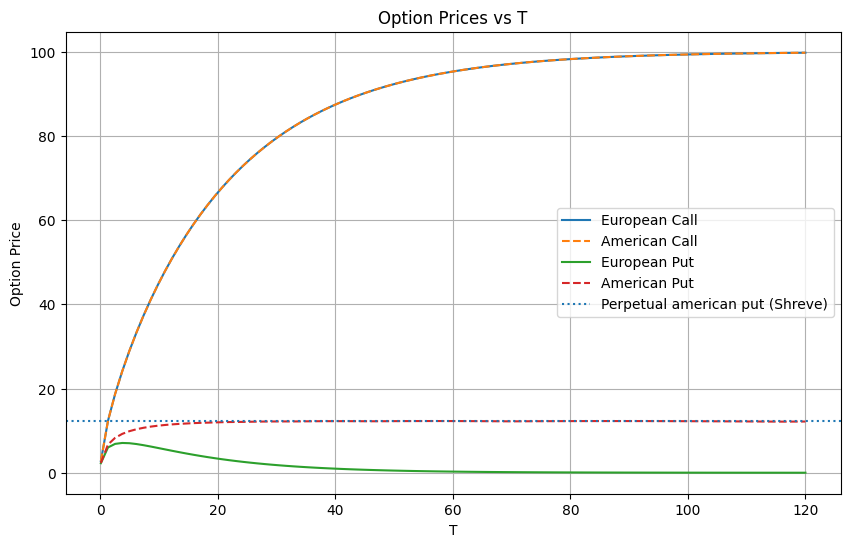

In [ ]:
lim_ame_put_price = perpetual_american_put(BASE_S0, BASE_K, BASE_R, BASE_SIGMA)
ax = analyze_sensitivity('T', np.linspace(0.1, 120.0, 100), K_eq_S0_params)
ax.axhline(y=lim_ame_put_price, linestyle=':', label='Perpetual American put (Shreve)')
ax.legend()
plt.show()

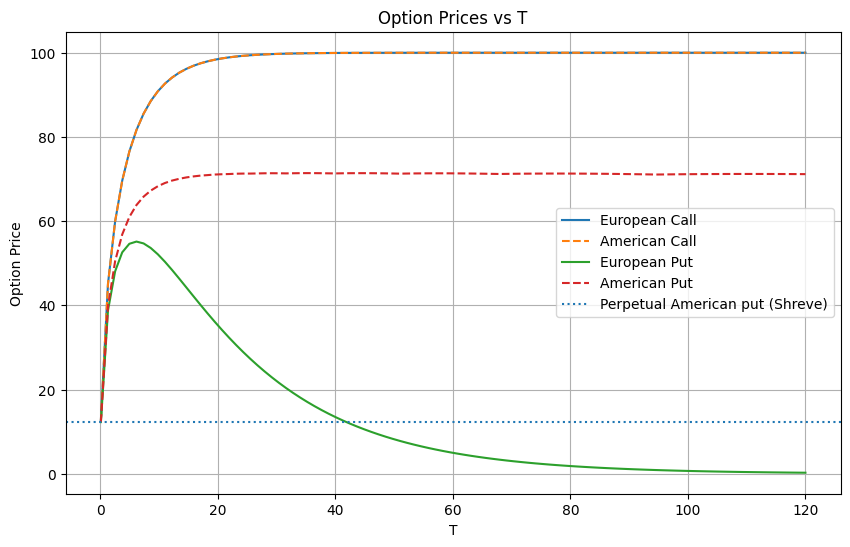

In [23]:
K_eq_S0_big_sigma = K_eq_S0_params.copy()
K_eq_S0_big_sigma['sigma'] = 1
lim_ame_put_price = perpetual_american_put(BASE_S0, BASE_K, BASE_R, BASE_SIGMA)
ax = analyze_sensitivity('T', np.linspace(0.1, 120.0, 100), K_eq_S0_big_sigma)
ax.axhline(y=lim_ame_put_price, linestyle=':', label='Perpetual American put (Shreve)')
ax.legend()
plt.show()

### Sensitivity to volatility $\sigma$
Sensitivity to $\sigma$ (vega) is given by
$$\frac{\partial V}{\partial \sigma} = S N'(d_+)\sqrt{T} = S_0 \sqrt{\frac{T}{2 \pi}} e^{-d_+^2/2}.$$

In [84]:
def d_plus(S0, K, T, r, sigma):
    return (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d_minus(S0, K, T, r, sigma):
    return d_plus(S0, K, T, r, sigma) - sigma * np.sqrt(T)

If $d_+$ is small, then $\frac{\partial V}{\partial \sigma} \approx S_0 \sqrt{\frac{T}{2 \pi}}$.
It can be verified that $d_+$ attains its minimum at $(\sigma^*)^2 = \frac{2}{T}\ln(S_0/K)+2r$.
The value of $d_+$ is then $\sigma^*$ itself.

In [85]:
def d_plus_min_sigma(S0, K, T, r):
    sigma_star_sq = (2 / T) * np.log(S0 / K) + 2 * r
    return np.sqrt(sigma_star_sq)

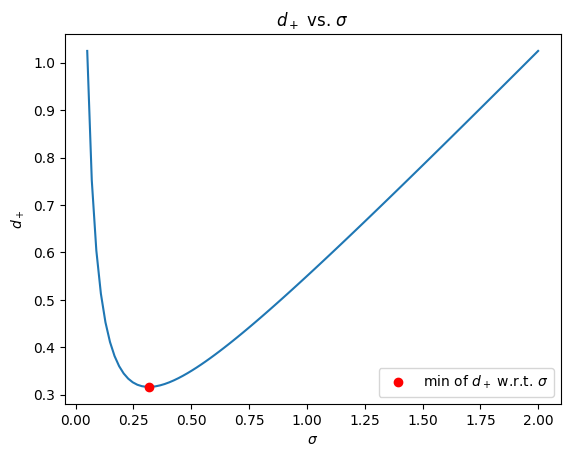

In [86]:
sigma_vals = np.linspace(0.05, 2.0, 100)
d_plus_vals = [d_plus(BASE_S0, BASE_K, BASE_T, BASE_R, sigma) for sigma in sigma_vals]
d_p_min_sigma = d_plus_min_sigma(BASE_S0, BASE_K, BASE_T, BASE_R)
plt.plot(sigma_vals, d_plus_vals)
plt.plot(d_p_min_sigma, d_p_min_sigma, 'ro', label=r'min of $d_+$ w.r.t. $\sigma$')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$d_+$')
plt.title(r'$d_+$ vs. $\sigma$')
plt.legend()
plt.show()

Let's verify that $V$ is approximately linear for $\sigma \approx \sigma^*$.

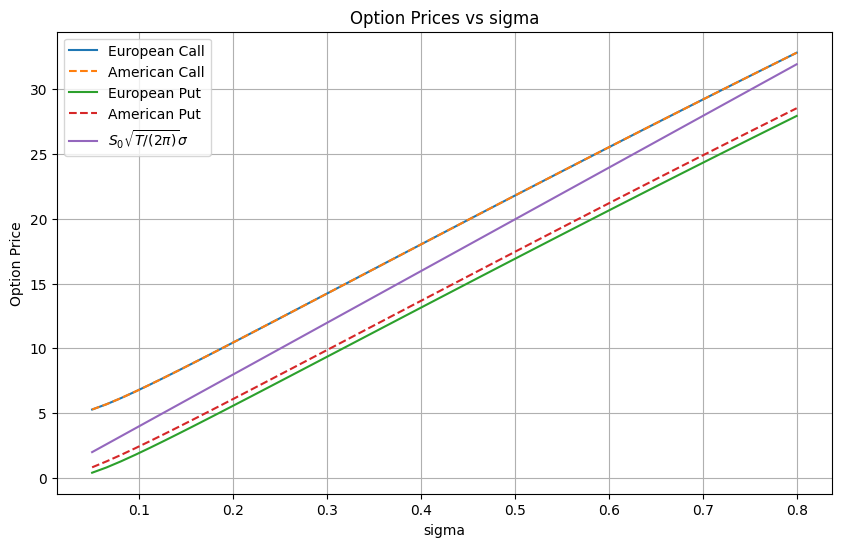

In [87]:
sigma_vals = np.linspace(0.05, 0.80, 50)
ax = analyze_sensitivity('sigma', sigma_vals, K_eq_S0_params)
vega_atm = BASE_S0 * np.sqrt(BASE_T / (2 * np.pi))
ax.plot(sigma_vals, sigma_vals * vega_atm, label=r'$S_0 \sqrt{T/(2 \pi)} \sigma$')
ax.legend()
plt.show()

As can be seen, the linear approximation becomes worse as we move away with $\sigma$ from $\sigma^*$.

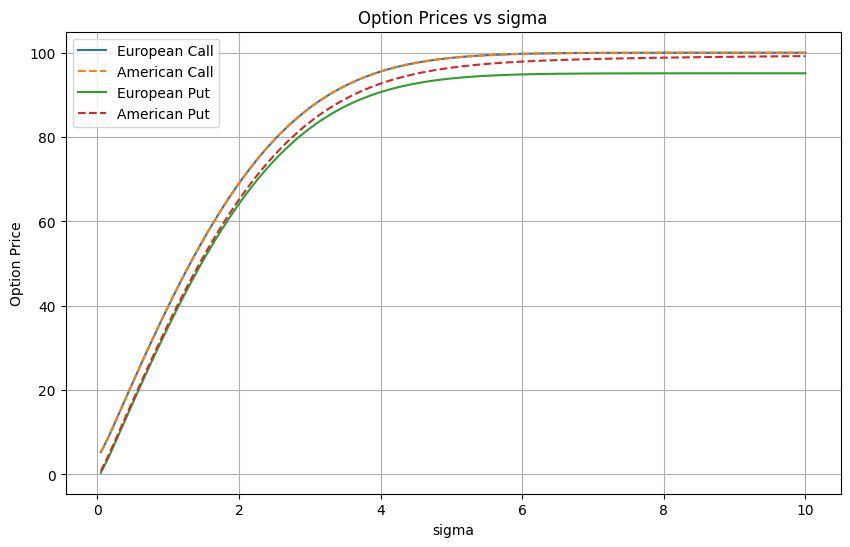

In [88]:
sigma_vals = np.linspace(0.05, 10, 100)
analyze_sensitivity('sigma', sigma_vals, K_eq_S0_params)
plt.show()

#### Limiting behavior
Notice that vega is nonnegative: the option price increases with $\sigma$.
Since $d_+$ is an increasing function of $\sigma$ (for $\sigma > \sigma^*$), as $\sigma$ increases the $e^{-d_+^2/2}$ factor in the formula for vega goes to zero and so the option price eventually flattens out.

We notice that $\lim_{\sigma \rightarrow \infty} d_+ = \infty$ and $\lim_{\sigma \rightarrow \infty} d_- = -\infty$.
Hence $N(d_+) \rightarrow 1$ and $N(d_-) \rightarrow 0$ as $\sigma \rightarrow \infty$ and hence Black-Scholes gives 
$$\lim_{\sigma \rightarrow \infty} C = S_0,$$
$$\lim_{\sigma \rightarrow \infty} P_E = Ke^{-rT}.$$

This also makes sense intuitively.
If $\sigma$ is large, then the stock will be either very expensive (compared to $K$) or worthless.
But the same can be said about the payoff of the call option: if $S_T$ is large, then the payoff $(S_T - K)^+ \approx S_T$ and when the stock crashes, the payoff is zero.
Therefore, the call behaves more or less the same as the stock and so they must be worth the same.

One property of the $\textrm{Lognormal}(\mu_L, \sigma_L^2)$ distribution is that as $\sigma_L \rightarrow \infty$, the probability mass is concentrated at zero [as illusrated here](https://www.desmos.com/calculator/s4cggsiudq) (CDF at 0 goes to 1) so the stock will almost certainly crash.
Therefore, the put will almost surely pay off $K$ at time $T$ which explains why it should be worth $Ke^{-rT}$ at time zero.

Since the stock is guaranteed to crash it makes no sense to wait to exercise an American put (it will pay off $K$ at exercise a.s. and postponing the exercise reduces $K$ by the factor of $e^{-rt}$).
This shows that the price of American put is $K$ in the limiting case as $\sigma \rightarrow \infty$, i.e.
$$\lim_{\sigma \rightarrow \infty} P_A = K.$$

⚠️ **Paradox**: if the stock crashes a.s. why is the call worth anything? ⚠️

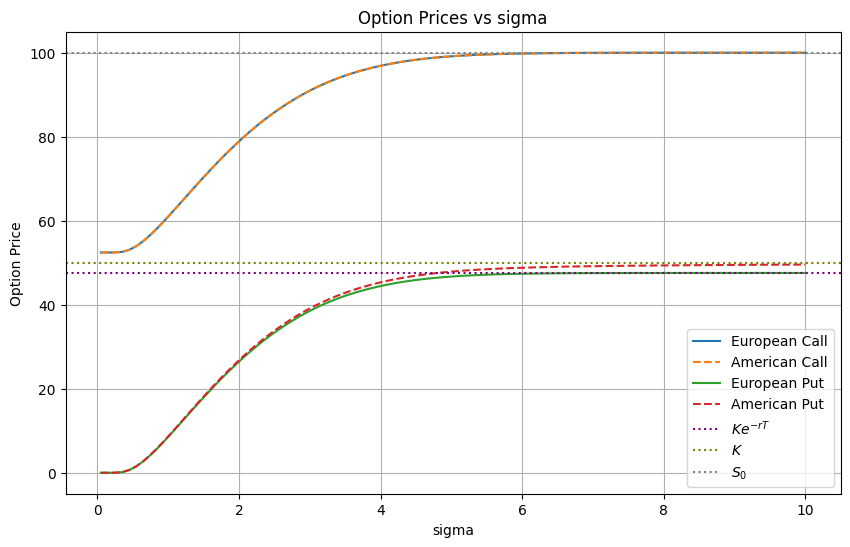

In [89]:
sigma_vals = np.linspace(0.05, 10, 100)
K_lt_S0_params = K_eq_S0_params.copy()
K_lt_S0_params['K'] = 50
ax = analyze_sensitivity('sigma', sigma_vals, K_lt_S0_params)
ax.axhline(y=K_lt_S0_params['K'] * np.exp(-K_lt_S0_params['r'] * K_lt_S0_params['T']), linestyle=':', color='purple', label=r'$Ke^{-rT}$')
ax.axhline(y=K_lt_S0_params['K'], linestyle=':', color='olive', label=r'$K$')
ax.axhline(y=K_lt_S0_params['S0'], linestyle=':', color='gray', label=r'$S_0$')
ax.legend()
plt.show()

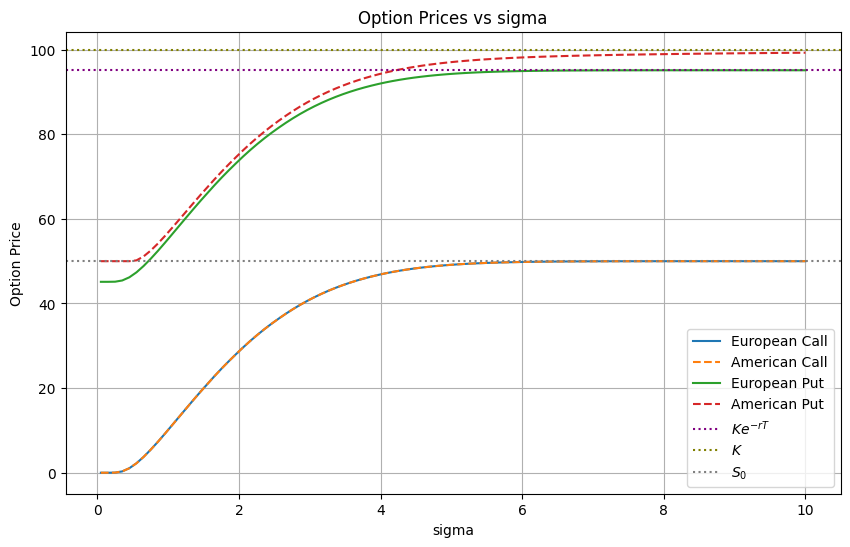

In [90]:
sigma_vals = np.linspace(0.05, 10, 100)
K_gt_S0_params = K_eq_S0_params.copy()
K_gt_S0_params['S0'] = 50
ax = analyze_sensitivity('sigma', sigma_vals, K_gt_S0_params)
ax.axhline(y=K_gt_S0_params['K'] * np.exp(-K_gt_S0_params['r'] * K_gt_S0_params['T']), linestyle=':', color='purple', label=r'$Ke^{-rT}$')
ax.axhline(y=K_gt_S0_params['K'], linestyle=':', color='olive', label=r'$K$')
ax.axhline(y=K_gt_S0_params['S0'], linestyle=':', color='gray', label=r'$S_0$')
ax.legend()
plt.show()

### Sensitivity to Interest Rate ($r$)
The Lognormal distribution has mean equal to $\exp(\mu + \sigma_L^2/2)$.
Since $\mu \propto r$, $E S_T \rightarrow \infty$ as $r \rightarrow \infty$.

This means that for $r$ large, the average payoff of a call is approx. the same as the stock ($K$ becomes negligible compared to large $S_T$).
This implies that 
$$\lim_{r \to \infty} C = S_0.$$
Since the stock is on average very valuable when $r$ is large, the put pays off nothing on average and so 
$$\lim_{r \to \infty} P_E = 0.$$
Alternative viewpoint is that a put will pay off at most $K$ at maturity but with large $r$, the present value of this best case-scenario payoff is approx. 0.
For an American put the situation is the same however we can exercise the option early.
For $r$ large it makes sense to exercise it straight away (if $K>S_0$) and get $K-S_0$ dollars that we can then invest in the money market.
This justifies that
$$\lim_{r \to \infty} P_E = (K-S_0)^+.$$

We can also derive these results from Balck-Scholes.
The derivative of the option price w.r.t. $r$ is called rho and it's given by
$$\frac{\partial C_E}{\partial r} = KTe^{-rT}N(d_-),$$
$$\frac{\partial P_E}{\partial r} = -KTe^{-rT}N(-d_-).$$
The signs of the derivatives indicate that $C_E$ is increasing with $r$ and $P_E$ is decreasing with $r$.

As $r \to \infty$, $d_+, d_- \to \infty$ and $N(d_-), N(d_+) \to 1$.
Hence, $\lim_{r \to \infty} C_E = S_0$ and $\lim_{r \to \infty} P_E = 0$.

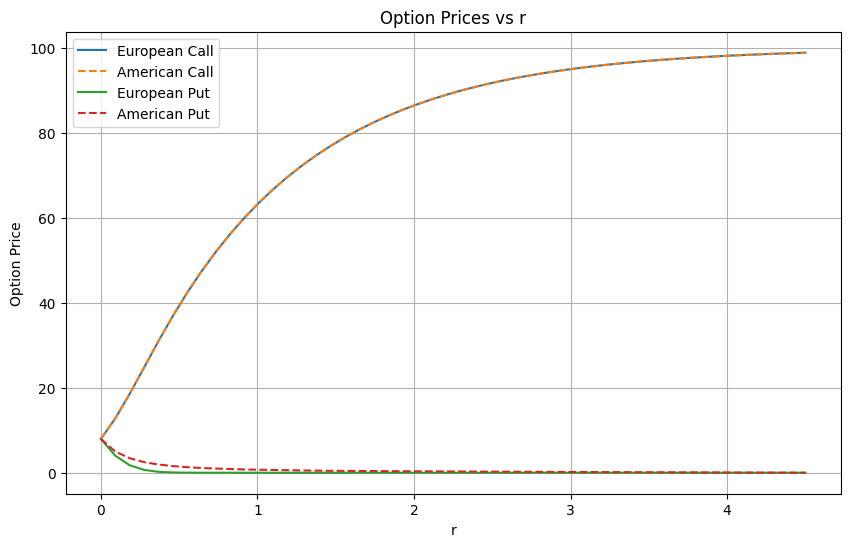

In [91]:
analyze_sensitivity('r', np.linspace(0.0, 4.5, 50), K_eq_S0_params)
plt.show()

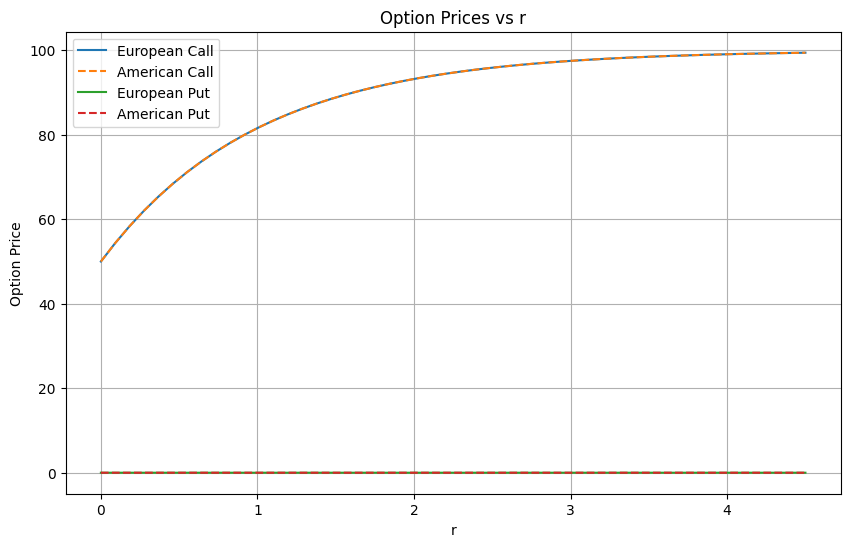

In [92]:
analyze_sensitivity('r', np.linspace(0.0, 4.5, 50), K_lt_S0_params)
plt.show()

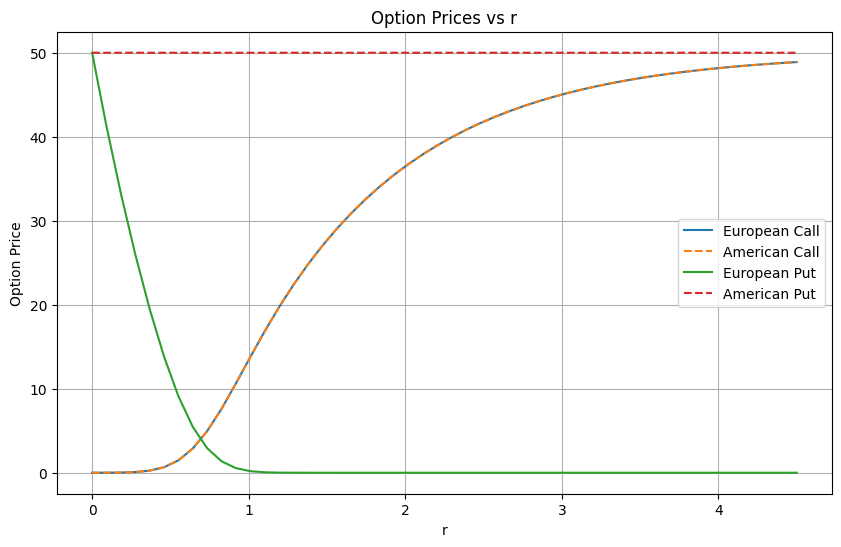

In [93]:
analyze_sensitivity('r', np.linspace(0.0, 4.5, 50), K_gt_S0_params)
plt.show()

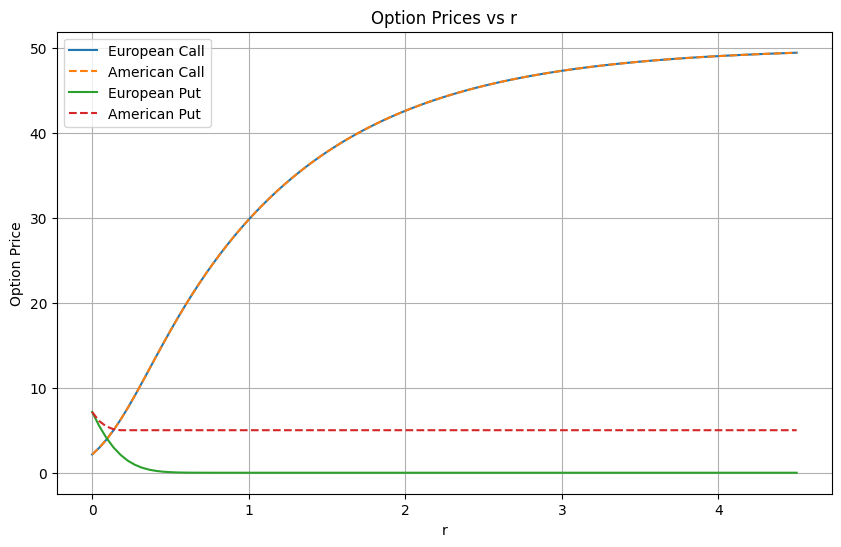

In [101]:
K_slightly_gt_S0_params = K_gt_S0_params.copy()
K_slightly_gt_S0_params['K'] = 55
analyze_sensitivity('r', np.linspace(0.0, 4.5, 100), K_slightly_gt_S0_params)
plt.show()

*   **Stock Price ($S_0$):** Calls are **monotonically increasing** (as stock goes up, right to buy is worth more). Puts are **monotonically decreasing**.
*   **Strike Price ($K$):** Calls are **monotonically decreasing** (higher strike means you pay more to buy the stock). Puts are **monotonically increasing**.
*   **Volatility ($\sigma$):** All 4 option types are **monotonically increasing** relative to volatility. Volatility means more uncertainty, which increases the chance of massive upside while the option's downside remains strictly capped at $0. 
*   **Interest Rate ($r$):** Higher rates increase Call values (because paying the strike price in the future means you save money today via discounting) and decrease Put values. 
*   **American vs. European Gaps:** As $T$ gets larger, or $r$ gets higher, the **American Put line pulls away and becomes noticeably more expensive than the European Put line**. This visual gap represents the "early exercise premium." Meanwhile, the American and European call lines should remain perfectly identical.

## Convergence analysis (sensitivity to the number of periods)

In [17]:
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
N_start, N_end = 5, 200

In [18]:
def generate_prices(option_class, S0, T, r, sigma, N_start, N_end):
    N_values = list(range(N_start, N_end))
    dt_values = [T / N for N in N_values]
    opt_prices = []

    for N in N_values:
        dt = T / N
        u = get_up_factor(sigma, dt)
        d = get_down_factor(sigma, dt)
        
        model = BinomialModel(S0=S0, N=N, dt=dt, u=u, d=d, r=r)
        opt_prices.append(option_class(K=K).price(model))

    return N_values, dt_values, opt_prices

In [19]:
def analyze_convergence(N_values, dt_values, bin_model_prices, bs_price=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(N_values, bin_model_prices, label='Binomial Tree', color='blue')
    if bs_price is not None:
        plt.axhline(y=bs_price, color='red', linestyle='--', label='Black-Scholes')
    plt.xlabel('Number of Steps (N)')
    plt.ylabel('Option Price')
    plt.title('Convergence vs. N')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(dt_values, bin_model_prices, label='Binomial Tree', color='blue')
    if bs_price is not None:
        plt.axhline(y=bs_price, color='red', linestyle='--', label='Black-Scholes')
    plt.xlabel(r'Time Step ($\Delta t$)')
    plt.gca().invert_xaxis() # invert x-axis
    plt.ylabel('Option Price')
    plt.title(r'Convergence vs. $\Delta t$')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### European call

In [ ]:
from scipy.stats import norm

# reference: https://en.wikipedia.org/wiki/Black–Scholes_model#Black–Scholes_formula
def black_scholes_european_call(S0, K, T, r, sigma):
    d_plus = d_plus(S0, K, T, r, sigma)
    d_minus = d_minus(S0, K, T, r, sigma)
    return S0 * norm.cdf(d_plus) - K * np.exp(-r * T) * norm.cdf(d_minus)

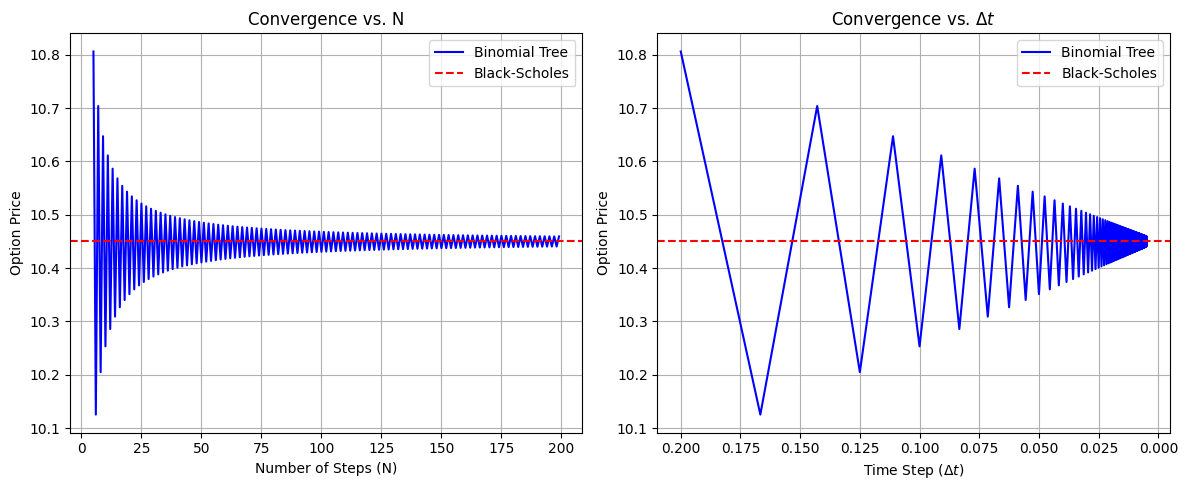

In [21]:
bs_call_price = black_scholes_european_call(S0, K, T, r, sigma)
N_values, dt_values, eur_call_prices = generate_prices(EuropeanCall, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, eur_call_prices, bs_call_price)

### European put

In [22]:
# reference: https://en.wikipedia.org/wiki/Black–Scholes_model#Black–Scholes_formula
def black_scholes_european_put(S0, K, T, r, sigma):
    return K * np.exp(-r * T) - S0 + black_scholes_european_call(S0, K, T, r, sigma)

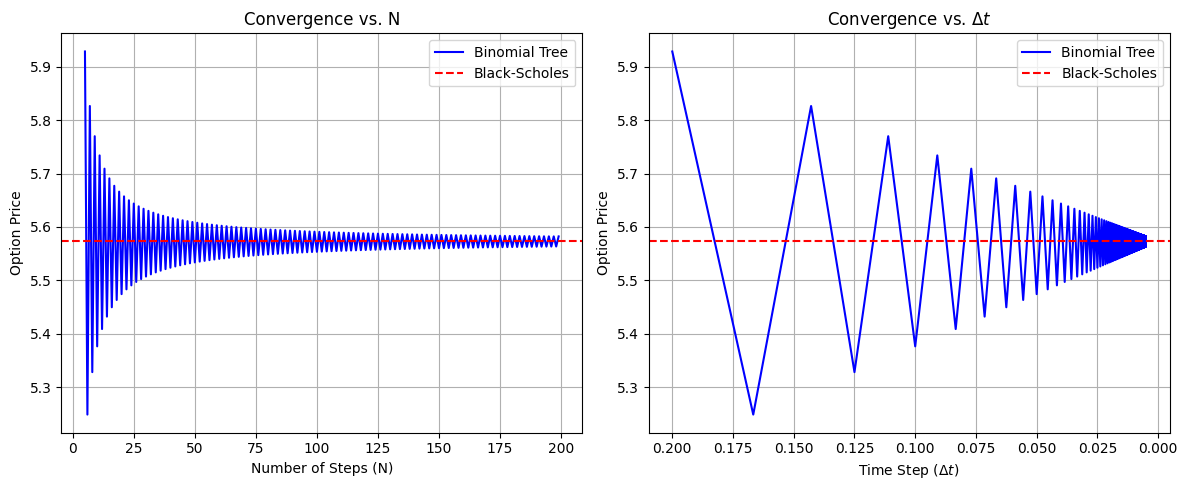

In [23]:
bs_put_price = black_scholes_european_put(S0, K, T, r, sigma)
N_values, dt_values, eur_put_prices = generate_prices(EuropeanPut, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, eur_put_prices, bs_put_price)

### American call

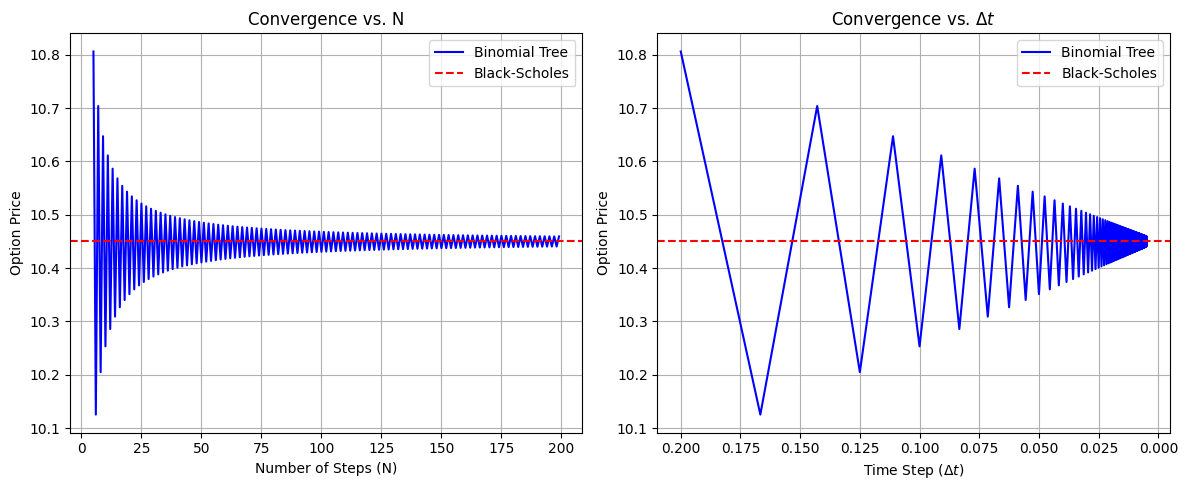

In [24]:
bs_call_price = black_scholes_european_call(S0, K, T, r, sigma)
N_values, dt_values, ame_call_prices = generate_prices(AmericanCall, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, ame_call_prices, bs_call_price)

### American put

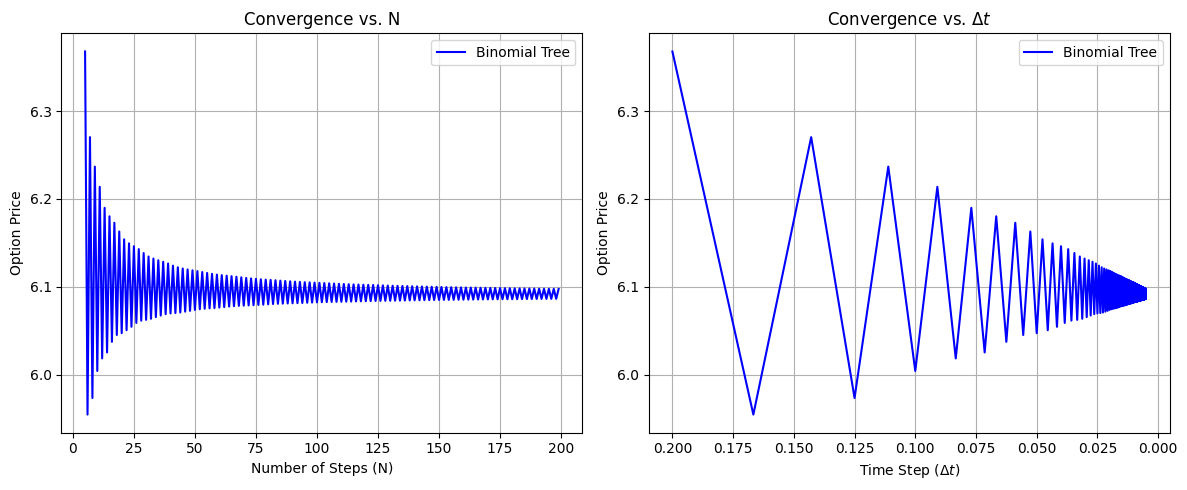

In [25]:
N_values, dt_values, ame_put_prices = generate_prices(AmericanPut, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, ame_put_prices)